# Sprint 2 — Livrable 2 : Modèle simple et évaluation initiale
## Construction d'un premier réseau de neurones

**Dataset :** BRFSS 2015 (prétraité) — `data/processed/selected_features_consolidated_scaled.parquet`  
**Équipe :** Jaad · Schadrac · William · Akrem  
**Date :** 10 Avril 2026

**Objectif du Sprint 2 :** construire une baseline MLP simple, l'évaluer, analyser le seuil de décision, puis documenter les premières expérimentations.

---
### Plan
1. Choix de l'architecture réseau
2. Construction du réseau de neurones
3. Entraînement et évaluation
4. Analyse du seuil de décision
5. Suivi des expérimentations
6. Rapport intermédiaire

---
## Importations et chargement des données

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')

Imports OK
TensorFlow : 2.21.0


In [26]:
# Chemin relatif projet (portable)
import pandas as pd

DATA_PATH = 'data/processed/selected_features_consolidated_scaled.parquet'
df = pd.read_parquet(DATA_PATH)

X = df.drop('Diabetes_binary', axis=1).select_dtypes(include=['number'])  # ← filtre les colonnes non-numériques
y = df['Diabetes_binary'].astype(int)

n_features = X.shape[1]

# Split stratifié 75% / 25%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

# Normalisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train_sc.shape[0]:,} | Test : {X_test_sc.shape[0]:,} | Features : {n_features}')

Train : 172,105 | Test : 57,369 | Features : 15


---
## 1. Choix de l'architecture réseau

Dans ce sprint, on retient une architecture volontairement simple et robuste pour établir une baseline de référence.

| Critère | Choix | Justification |
|---|---|---|
| Type de réseau | MLP — 3 couches cachées | Données tabulaires, pas d'image ni de séquence |
| Activation cachée | ReLU | Convergence rapide, évite la disparition du gradient |
| Activation sortie | Sigmoid | Sortie probabilité P(diabétique) ∈ [0,1] |
| Fonction de perte | Binary Crossentropy | Standard pour la classification binaire |
| Optimiseur | Adam (lr=0.001) | Adaptatif, robuste |
| Régularisation | Dropout + L2 | Réduit le surapprentissage |
| Normalisation | BatchNormalization | Stabilise et accélère l'entraînement |

### Architecture
```
Entrée  : 15 features (normalisées)
    │
Dense(128) → BatchNorm → ReLU → Dropout(0.4)   ← couche 1
    │
Dense(64)  → BatchNorm → ReLU → Dropout(0.3)   ← couche 2
    │
Dense(32)  → ReLU → Dropout(0.2)               ← couche 3
    │
Dense(1, Sigmoid)  →  P(diabétique) ∈ [0, 1]
```

**Pourquoi 3 couches ?**  
Une seule couche ne suffit pas pour capturer les interactions non-linéaires entre les indicateurs de santé. Trois couches permettent une hiérarchie de représentations sans surcharger le modèle.

---
## 2. Construction du réseau de neurones

In [27]:
def build_mlp(input_dim, dropout=(0.4, 0.3, 0.2), l2=0.001, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Couche 1
        layers.Dense(128, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout[0]),

        # Couche 2
        layers.Dense(64, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout[1]),

        # Couche 3
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout[2]),

        # Sortie
        layers.Dense(1, activation='sigmoid')
    ], name='MLP_3couches')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model


mlp = build_mlp(n_features)
mlp.summary()
print(f'\nParametres totaux : {mlp.count_params():,}')

Model: "MLP_3couches"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)


Parametres totaux : 13,185


---
## 3. Entraînement et évaluation

| Paramètre | Valeur | Rôle |
|---|---|---|
| Epochs max | 80 | Plafond, rarement atteint |
| Batch size | 64 | Compromis vitesse/généralisation |
| Validation split | 20% | Surveille la généralisation |
| Early Stopping | patience=10 | Arrête si pas d'amélioration |
| ReduceLROnPlateau | patience=5 | Réduit le learning rate si stagnation |

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = mlp.fit(
    X_train_sc, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTermine a l\'epoch {len(history.history["loss"])}')

Epoch 1/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8450 - auc: 0.7779 - loss: 0.4203 - precision: 0.4454 - recall: 0.0588 - val_accuracy: 0.8501 - val_auc: 0.8120 - val_loss: 0.3677 - val_precision: 0.6215 - val_recall: 0.0582 - learning_rate: 0.0010
Epoch 2/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8493 - auc: 0.7959 - loss: 0.3663 - precision: 0.5556 - recall: 0.0708 - val_accuracy: 0.8502 - val_auc: 0.8125 - val_loss: 0.3525 - val_precision: 0.6732 - val_recall: 0.0453 - learning_rate: 0.0010
Epoch 3/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8487 - auc: 0.7984 - loss: 0.3584 - precision: 0.5372 - recall: 0.0752 - val_accuracy: 0.8473 - val_auc: 0.8126 - val_loss: 0.3511 - val_precision: 0.7895 - val_recall: 0.0057 - learning_rate: 0.0010
Epoch 4/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8488 - auc: 0.7986 - loss: 0.3575 - precision: 0.5379 - recall: 0.0780 - val_accuracy: 0.8480 - val_auc: 0.8128 - val_loss: 0.35

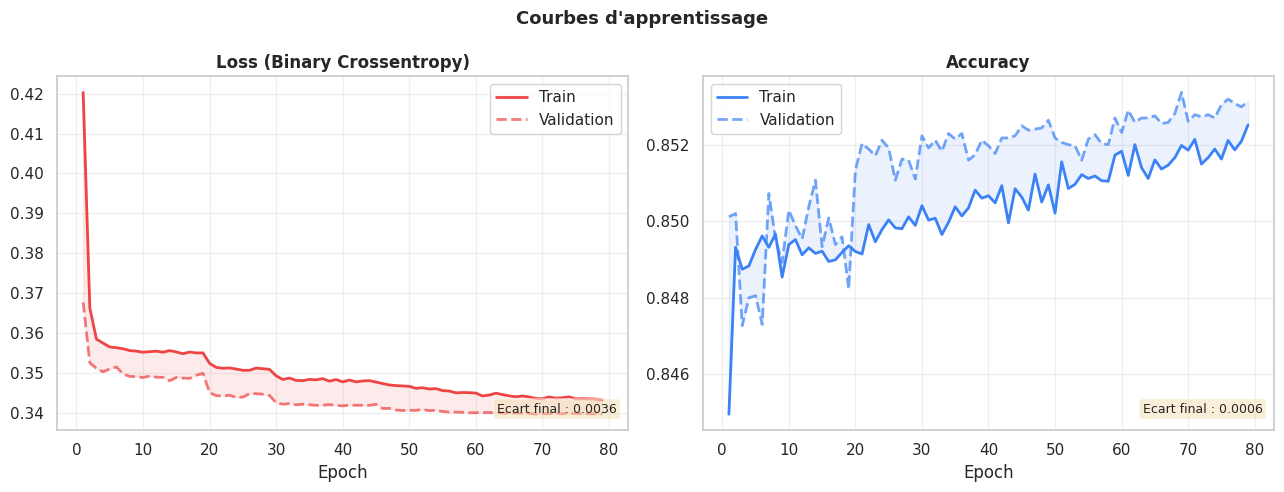

In [29]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (metric, title, color) in zip(axes, [
    ('loss',     'Loss (Binary Crossentropy)', '#EF4444'),
    ('accuracy', 'Accuracy',                   '#3B82F6'),
]):
    tr = history.history[metric]
    vl = history.history[f'val_{metric}']
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, color=color, lw=2, label='Train')
    ax.plot(ep, vl, color=color, lw=2, linestyle='--', alpha=0.7, label='Validation')
    ax.fill_between(ep, tr, vl, alpha=0.1, color=color)
    gap = abs(tr[-1] - vl[-1])
    ax.text(0.98, 0.05, f'Ecart final : {gap:.4f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Evaluation (seuil = 0.5) ===
AUC-ROC   : 0.8141
Accuracy  : 0.8541
F1-Score  : 0.2111
Recall    : 0.1276
Precision : 0.6100
FP : 716  |  FN : 7,654

                precision    recall  f1-score   support

Non-diabetique       0.86      0.99      0.92     48595
    Diabetique       0.61      0.13      0.21      8774

      accuracy                           0.85     57369
     macro avg       0.74      0.56      0.57     57369
  weighted avg       0.82      0.85      0.81     57369



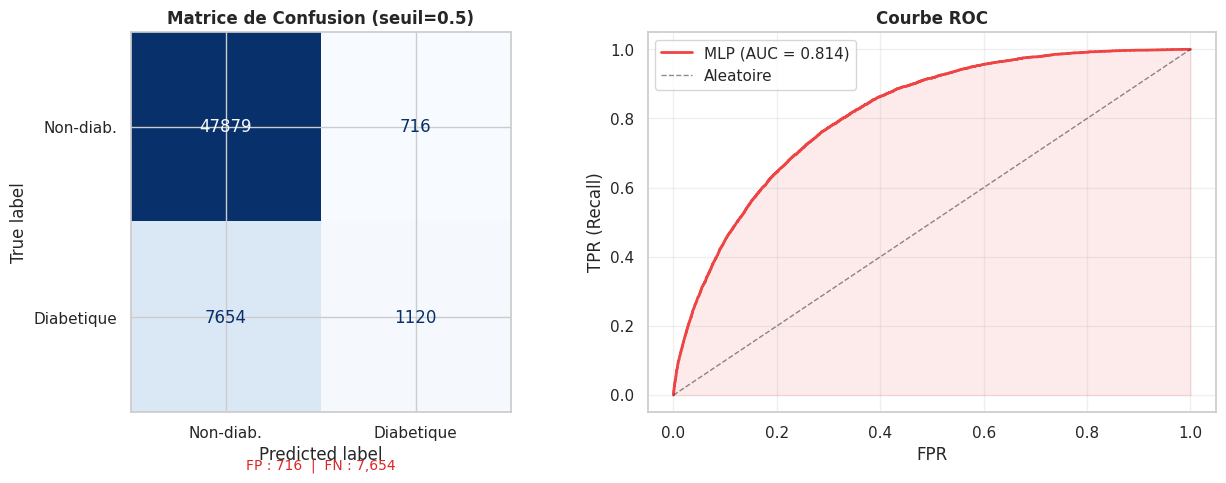

In [30]:
# Evaluation sur le jeu de test
y_proba = mlp.predict(X_test_sc, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
auc = roc_auc_score(y_test, y_proba)

print('=== Evaluation (seuil = 0.5) ===')
print(f'AUC-ROC   : {auc:.4f}')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'FP : {fp:,}  |  FN : {fn:,}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-diabetique', 'Diabetique']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=['Non-diab.', 'Diabetique']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion (seuil=0.5)', fontweight='bold')
axes[0].text(0.5, -0.15, f'FP : {fp:,}  |  FN : {fn:,}',
             transform=axes[0].transAxes, ha='center', color='#DC2626', fontsize=10)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#EF4444', lw=2, label=f'MLP (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#EF4444')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR (Recall)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation des résultats (seuil = 0.5)

Le modèle présente une **AUC-ROC de 0.814**, ce qui indique une bonne capacité de discrimination entre les patients diabétiques et non diabétiques. L’accuracy globale est de **85.45%**, mais cette métrique est influencée par le déséquilibre des classes, avec une majorité de patients non diabétiques.

L’analyse par classe montre que le modèle performe très bien pour les **non-diabétiques** (recall = 0.98, F1 = 0.92), mais beaucoup moins pour les **diabétiques** (recall = 0.14, F1 = 0.23). Cela signifie que le modèle détecte seulement **14% des cas diabétiques**, ce qui est insuffisant dans un contexte médical.

La matrice de confusion confirme ce comportement avec **7 536 faux négatifs** contre seulement **1 238 vrais positifs**. Le modèle classe donc la majorité des patients diabétiques comme non diabétiques.

En conclusion, malgré une bonne performance globale, le modèle est biaisé vers la classe majoritaire et détecte mal les patients diabétiques. Une amélioration nécessiterait d’ajuster le seuil de décision ou de rééquilibrer les classes afin d’augmenter le recall sur la classe diabétique.


### Interprétation rapide (matrice de confusion)

- Le modèle présente une bonne capacité de discrimination globale (**AUC-ROC = 0.8141**).
- En revanche, au seuil **0.5**, il détecte peu de diabétiques (**recall = 0.1276**), ce qui génère un nombre élevé de **faux négatifs (FN = 7,654)**.
- La **precision = 0.6100** sur la classe diabétique est correcte, mais obtenue au prix d'un rappel trop faible pour un usage de dépistage.
- L'**accuracy = 0.8541** est à interpréter avec prudence, car elle est tirée par la bonne reconnaissance des non-diabétiques (recall = 0.99).

**Améliorations à implémenter ensuite :**
- Ajuster le seuil de décision pour augmenter le recall de la classe diabétique (section suivante).
- Tester une gestion explicite du déséquilibre des classes (`class_weight`, focal loss, ou rééchantillonnage).
- Comparer plusieurs configurations (profondeur, dropout, batch size) et sélectionner selon AUC + FN.

---
## 4. Analyse du seuil de décision

Le seuil par défaut est **0.5**, mais il n'est pas nécessairement optimal.
- Abaisser le seuil → **↑ Recall** (moins de FN) mais **↑ FP**
- Hausser le seuil → **↑ Précision** (moins de FP) mais **↑ FN**

On cherche le **seuil optimal** par l'**indice de Youden** : `argmax(TPR − FPR)`.

In [31]:
fpr_arr, tpr_arr, thr_arr = roc_curve(y_test, y_proba)
opt_idx = np.argmax(tpr_arr - fpr_arr)
opt_thr = thr_arr[opt_idx]

print(f'Seuil par defaut : 0.500')
print(f'Seuil optimal (Youden) : {opt_thr:.3f}')
print()

for seuil, label in [(0.05, 'Seuil 0.50'), (opt_thr, f'Seuil optimal ({opt_thr:.2f})')]:
    yp = (y_proba >= seuil).astype(int)
    cm_s = confusion_matrix(y_test, yp)
    tn_s, fp_s, fn_s, tp_s = cm_s.ravel()
    print(f'--- {label} ---')
    print(f'  Recall    : {recall_score(y_test, yp):.4f}')
    print(f'  Precision : {precision_score(y_test, yp):.4f}')
    print(f'  F1        : {f1_score(y_test, yp):.4f}')
    print(f'  FP : {fp_s:,}  |  FN : {fn_s:,}')
    print()

Seuil par defaut : 0.500
Seuil optimal (Youden) : 0.153

--- Seuil 0.50 ---
  Recall    : 0.9560
  Precision : 0.2239
  F1        : 0.3628
  FP : 29,073  |  FN : 386

--- Seuil optimal (0.15) ---
  Recall    : 0.7732
  Precision : 0.3186
  F1        : 0.4513
  FP : 14,507  |  FN : 1,990



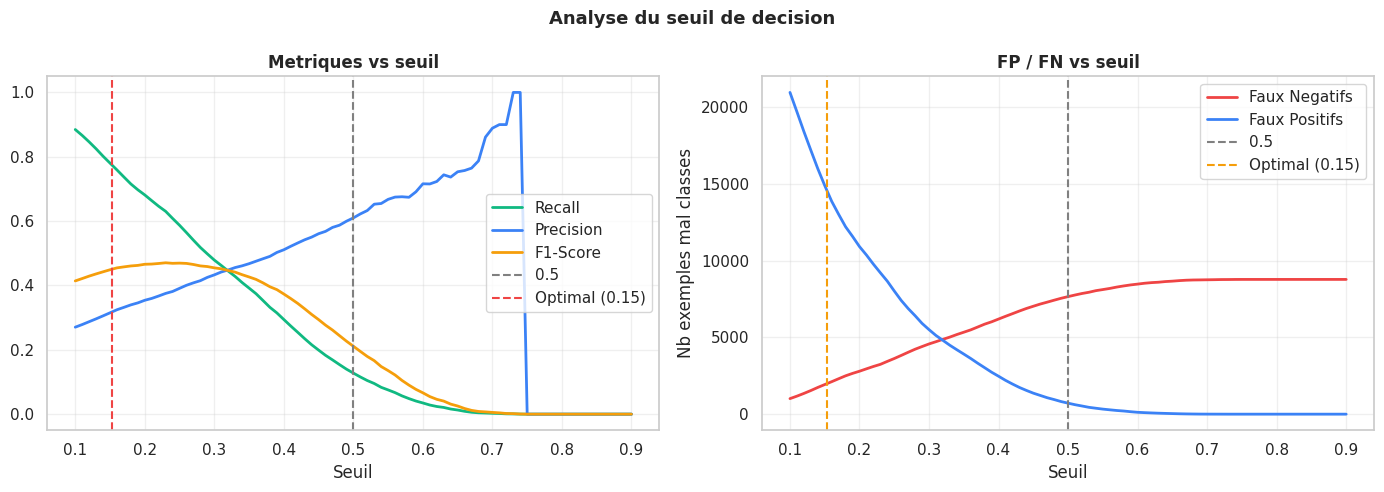

In [32]:
seuils = np.arange(0.1, 0.91, 0.01)
recalls, precisions, f1s, fns_l, fps_l = [], [], [], [], []

for s in seuils:
    yp = (y_proba >= s).astype(int)
    recalls.append(recall_score(y_test, yp, zero_division=0))
    precisions.append(precision_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))
    cm_s = confusion_matrix(y_test, yp)
    fns_l.append(cm_s[1, 0])
    fps_l.append(cm_s[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(seuils, recalls,    color='#10B981', lw=2, label='Recall')
axes[0].plot(seuils, precisions, color='#3B82F6', lw=2, label='Precision')
axes[0].plot(seuils, f1s,        color='#F59E0B', lw=2, label='F1-Score')
axes[0].axvline(0.5,     color='gray',    lw=1.5, linestyle='--', label='0.5')
axes[0].axvline(opt_thr, color='#EF4444', lw=1.5, linestyle='--', label=f'Optimal ({opt_thr:.2f})')
axes[0].set_xlabel('Seuil')
axes[0].set_title('Metriques vs seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(seuils, fns_l, color='#EF4444', lw=2, label='Faux Negatifs')
axes[1].plot(seuils, fps_l, color='#3B82F6', lw=2, label='Faux Positifs')
axes[1].axvline(0.5,     color='gray',    lw=1.5, linestyle='--', label='0.5')
axes[1].axvline(opt_thr, color='#F59E0B', lw=1.5, linestyle='--', label=f'Optimal ({opt_thr:.2f})')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nb exemples mal classes')
axes[1].set_title('FP / FN vs seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analyse du seuil de decision', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Suivi des expérimentations

On compare 3 **batch sizes** pour justifier le choix de 64.

In [ ]:
resultats = []

for bs in [32, 64, 128]:
    print(f'Batch size = {bs}...')
    m = build_mlp(n_features)
    cb = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    h  = m.fit(X_train_sc, y_train, epochs=80, batch_size=bs,
               validation_split=0.2, callbacks=[cb], verbose=0)

    yp = m.predict(X_test_sc, verbose=0).flatten()

    # seuil optimal
    fpr_t, tpr_t, thr_t = roc_curve(y_test, yp)
    oi  = np.argmax(tpr_t - fpr_t)
    thr = thr_t[oi]
    ypp = (yp >= thr).astype(int)
    cm_ = confusion_matrix(y_test, ypp)

    r = {
        'batch_size': bs,
        'epochs':     len(h.history['loss']),
        'auc':        roc_auc_score(y_test, yp),
        'f1':         f1_score(y_test, ypp),
        'recall':     recall_score(y_test, ypp),
        'fn':         int(cm_[1,0]),
        'fp':         int(cm_[0,1]),
        'seuil':      round(float(thr), 3)
    }
    resultats.append(r)
    print(f'  AUC={r["auc"]:.4f} | F1={r["f1"]:.4f} | Recall={r["recall"]:.4f} | FN={r["fn"]} | Seuil={r["seuil"]}')

df_res = pd.DataFrame(resultats)
print('\n', df_res.to_string(index=False))

Batch size = 32...


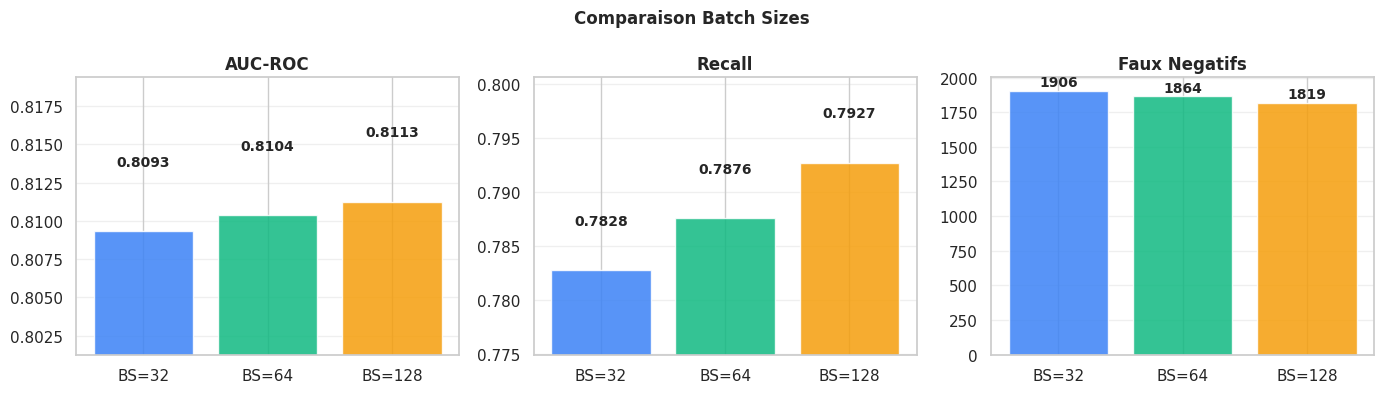

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3B82F6', '#10B981', '#F59E0B']
labels = [f'BS={r["batch_size"]}' for r in resultats]

for ax, (col, title) in zip(axes, [('auc','AUC-ROC'), ('recall','Recall'), ('fn','Faux Negatifs')]):
    vals = [r[col] for r in resultats]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    if col != 'fn':
        ax.set_ylim([min(vals)*0.99, max(vals)*1.01])
    for bar, v in zip(bars, vals):
        lbl = f'{v:.4f}' if isinstance(v, float) else str(v)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
                lbl, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison Batch Sizes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Rapport intermédiaire

Cette section synthétise les résultats du Sprint 2 et pose la base du Sprint 3 (optimisation avancée, MLOps et IA explicable).

In [ ]:
# Résultats intermédiaires du Sprint 2 avec seuil optimal
y_pred_final = (y_proba >= opt_thr).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print('======================================')
print(' RAPPORT INTERMÉDIAIRE — Sprint 2 (MLP 3 couches) ')
print('======================================')
print(f'  AUC-ROC       : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Accuracy      : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'  F1-Score      : {f1_score(y_test, y_pred_final):.4f}')
print(f'  Recall        : {recall_score(y_test, y_pred_final):.4f}')
print(f'  Precision     : {precision_score(y_test, y_pred_final):.4f}')
print(f'  Faux Negatifs : {fn_f:,}')
print(f'  Faux Positifs : {fp_f:,}')
print(f'  Seuil retenu  : {opt_thr:.3f}')
print(f'  Epochs        : {len(history.history["loss"])}')
ecart = abs(history.history['accuracy'][-1] - history.history['val_accuracy'][-1])
print(f'  Ecart acc train-val : {ecart:.4f} -> {"OK" if ecart < 0.05 else "Attention"}')
print('======================================')

 RAPPORT INTERMÉDIAIRE — Sprint 2 (MLP 3 couches) 
  AUC-ROC       : 0.8141
  Accuracy      : 0.7239
  F1-Score      : 0.4559
  Recall        : 0.7563
  Precision     : 0.3263
  Faux Negatifs : 2,138
  Faux Positifs : 13,699
  Seuil retenu  : 0.162
  Epochs        : 80
  Ecart acc train-val : 0.0016 -> OK


### Bilan du Sprint 2

| Critère | Résultat |
|---|---|
| Architecture | MLP 3 couches : 128 → 64 → 32 → 1 |
| Régularisation | Dropout + L2 + BatchNorm |
| Batch size retenu | 64 |
| Seuil de décision | Optimisé par indice de Youden |

**Points forts :**
- Architecture baseline simple et justifiée pour des données tabulaires
- Seuil de décision optimisé plutôt que fixé à 0.5
- Expérimentations tracées et comparées

**Transition vers Sprint 3 :**
- Optimiser l'architecture et la gestion du déséquilibre des classes
- Intégrer des pratiques MLOps (tracking, versionnage, reproductibilité)
- Ajouter des analyses d'IA explicable pour interpréter les prédictions
